In [24]:
import pandas as pd
import matplotlib.pyplot as plt 
from scipy.stats import chi2_contingency
from pathlib import Path

In [25]:
#Create a path to load the csv file New York arrest data year to date. 
DATA_PATH = (
    Path("Data_Project_1")
    /"NYPD_Arrest_Data__Year_to_Date__20240702.csv"
)

nypd_df = pd.read_csv(DATA_PATH)

In [26]:
#Rename columns in the csv 

COLUMN_NAMES = {
    "ARREST_KEY": "arrest_key",
    "ARREST_DATE": "arrest_date",
    "ARREST_BORO": "borough",
    "OFNS_DESC": "offense_type",
    "LAW_CAT_CD": "offense_level",
    "AGE_GROUP": "age_group",
    "PERP_SEX": "gender",
    "PERP_RACE": "race",
    "Latitude": "latitude",
    "Longitude": "longitude"
}

arrests_df = nypd_df.rename(columns=COLUMN_NAMES).copy()

arrests_df

,arrest_key,arrest_date,PD_CD,PD_DESC,KY_CD,offense_type,LAW_CODE,offense_level,borough,JURISDICTION_CODE,ARREST_PRECINCT,age_group,gender,race,X_COORD_CD,Y_COORD_CD,latitude,longitude,New Georeferenced Column
0,280255493,01/10/2024,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 1601001,F,M,0,26,<18,M,BLACK,996342,236149,40.814845,-73.956312,POINT (-73.956312 40.814845)
1,279805419,01/02/2024,157.0,RAPE 1,104.0,RAPE,PL 1303501,F,K,0,77,25-44,M,WHITE HISPANIC,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)
2,279895750,01/03/2024,101.0,ASSAULT 3,344.0,ASSAULT 3 & RELATED OFFENSES,PL 1200001,M,Q,0,106,65+,F,WHITE,1026836,180689,40.662526,-73.846499,POINT (-73.846499 40.662526)
3,280809090,01/19/2024,511.0,"CONTROLLED SUBSTANCE, POSSESSI",235.0,DANGEROUS DRUGS,PL 2200300,M,B,0,49,45-64,M,BLACK,1027430,251104,40.855793,-73.843908,POINT (-73.843908 40.855793)
4,280357135,01/11/2024,109.0,"ASSAULT 2,1,UNCLASSIFIED",106.0,FELONY ASSAULT,PL 1200502,F,K,2,81,25-44,F,BLACK,1002457,192292,40.694456,-73.934343,POINT (-73.934343 40.694456)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63616,282877412,02/27/2024,339.0,"LARCENY,PETIT FROM OPEN AREAS,",341.0,PETIT LARCENY,PL 1552500,M,K,0,60,45-64,M,WHITE HISPANIC,987154,149165,40.576100,-73.989545,POINT (-73.989545 40.5761)
63617,283628088,03/12/2024,511.0,"CONTROLLED SUBSTANCE, POSSESSI",235.0,DANGEROUS DRUGS,PL 2200300,M,M,0,13,45-64,M,BLACK,985689,208933,40.740151,-73.994805,POINT (-73.994805 40.740151)
63618,283387006,03/07/2024,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 160102A,F,K,0,73,25-44,M,BLACK,1008227,183789,40.671104,-73.913562,POINT (-73.913562 40.671104)
63619,283013910,03/01/2024,922.0,"TRAFFIC,UNCLASSIFIED MISDEMEAN",348.0,VEHICLE AND TRAFFIC LAWS,VTL05110A4,M,K,0,83,25-44,F,BLACK,1007120,193913,40.698894,-73.917522,POINT (-73.91752179908735 40.698893568968515)


In [27]:
#Create a function to plot all necessary charts and elimiate redundant code. 

def plot_category_counts(
        df,
        column,
        title,
        xlabel,
        top_n=None,
        color="steelblue",
):
    counts = df[column].value_counts().head(top_n)

    ax = counts.sort_values().plot(
        kind="barh",
        figsize=(8,5),
        color=color,
    )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

    return counts 

In [28]:
# Inspect the dataset dimensions and the column data types. 

print(f"rows: {arrests_df.shape[0]:,}")
print(f"columns: {arrests_df.shape[1]}")

rows: 63,621
columns: 19


In [29]:
# Count and calculate the percentage of missing values. 

missing_values = pd.DataFrame({
    "missing_count": arrests_df.isna().sum(),
    "missing_percentage": (
        arrests_df.isna().mean() * 100
    ).round(2),
})

missing_values = missing_values[
    missing_values["missing_count"] > 0
].sort_values(
    by= "missing_percentage",
    ascending=False,
)

missing_values

,missing_count,missing_percentage
offense_level,402,0.63
KY_CD,9,0.01
PD_CD,2,0.00


In [30]:
# Check for duplicated rows and duplicated arrests keys.

duplicate_rows = arrests_df.duplicated().sum()
duplicate_arrest_keys = arrests_df["arrest_key"].duplicated().sum()

print(f"Fully duplicated rows: {duplicate_rows:,}")
print(f"Duplicated arrest keys: {duplicate_arrest_keys:,}")

Fully duplicated rows: 0
Duplicated arrest keys: 0


In [31]:
# Examine the unique values in important categorical columns. 

category_columns = [
    "borough",
    "offense_level",
    "age_group", 
    "gender",
    "race",
]

for column in category_columns:
    print(f"\n{column.upper()}")
    print(arrests_df[column].value_counts(dropna=False))


BOROUGH
borough
K    17402
M    15324
B    14221
Q    13782
S     2892
Name: count, dtype: int64

OFFENSE_LEVEL
offense_level
M         35580
F         26653
V           775
NaN         402
9           155
I            54
(null)        2
Name: count, dtype: int64

AGE_GROUP
age_group
25-44    37254
45-64    12315
18-24    10684
<18       2327
65+       1041
Name: count, dtype: int64

GENDER
gender
M    52432
F    11189
Name: count, dtype: int64

RACE
race
BLACK                             29466
WHITE HISPANIC                    17191
WHITE                              6607
BLACK HISPANIC                     6336
ASIAN / PACIFIC ISLANDER           3543
UNKNOWN                             293
AMERICAN INDIAN/ALASKAN NATIVE      185
Name: count, dtype: int64


In [32]:
def clean_arrest_data(df):
    """Clean and prepare NYPD arrest data for analysis."""

    cleaned_df = df.copy()

    # Select text columns.
    text_columns = cleaned_df.select_dtypes(
        include="str"
    ).columns

    # Remove leading and trailing spaces.
    for column in text_columns:
        cleaned_df[column] = cleaned_df[column].str.strip()

    # Replace blank and null-like strings with missing values.
    cleaned_df[text_columns] = cleaned_df[
        text_columns
    ].replace(
        {
            "": pd.NA,
            "(null)": pd.NA,
        }
    )

    # Convert arrest date to datetime.
    cleaned_df["arrest_date"] = pd.to_datetime(
        cleaned_df["arrest_date"],
        errors="coerce",
    )

    # Convert coordinates to numeric values.
    cleaned_df["latitude"] = pd.to_numeric(
        cleaned_df["latitude"],
        errors="coerce",
    )

    cleaned_df["longitude"] = pd.to_numeric(
        cleaned_df["longitude"],
        errors="coerce",
    )

    # Remove completely duplicated records.
    cleaned_df = cleaned_df.drop_duplicates()

    # Remove duplicated arrest keys.
    cleaned_df = cleaned_df.drop_duplicates(
        subset="arrest_key",
        keep="first",
    )

    # Replace missing categorical values.
    categorical_columns = [
        "borough",
        "offense_type",
        "offense_level",
        "age_group",
        "gender",
        "race",
    ]

    cleaned_df[categorical_columns] = cleaned_df[
        categorical_columns
    ].fillna("UNKNOWN")

    return cleaned_df

In [33]:
cleaned_arrests_df = clean_arrest_data(arrests_df)

print(f"Original records: {len(arrests_df):,}")
print(f"Cleaned records: {len(cleaned_arrests_df):,}")

cleaned_arrests_df.head(20)

Original records: 63,621
Cleaned records: 63,621


,arrest_key,arrest_date,PD_CD,PD_DESC,KY_CD,offense_type,LAW_CODE,offense_level,borough,JURISDICTION_CODE,ARREST_PRECINCT,age_group,gender,race,X_COORD_CD,Y_COORD_CD,latitude,longitude,New Georeferenced Column
0,280255493,2024-01-10,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 1601001,F,M,0,26,<18,M,BLACK,996342,236149,40.814845,-73.956312,POINT (-73.956312 40.814845)
1,279805419,2024-01-02,157.0,RAPE 1,104.0,RAPE,PL 1303501,F,K,0,77,25-44,M,WHITE HISPANIC,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)
2,279895750,2024-01-03,101.0,ASSAULT 3,344.0,ASSAULT 3 & RELATED OFFENSES,PL 1200001,M,Q,0,106,65+,F,WHITE,1026836,180689,40.662526,-73.846499,POINT (-73.846499 40.662526)
3,280809090,2024-01-19,511.0,"CONTROLLED SUBSTANCE, POSSESSI",235.0,DANGEROUS DRUGS,PL 2200300,M,B,0,49,45-64,M,BLACK,1027430,251104,40.855793,-73.843908,POINT (-73.843908 40.855793)
4,280357135,2024-01-11,109.0,"ASSAULT 2,1,UNCLASSIFIED",106.0,FELONY ASSAULT,PL 1200502,F,K,2,81,25-44,F,BLACK,1002457,192292,40.694456,-73.934343,POINT (-73.934343 40.694456)
5,281488967,2024-02-01,157.0,RAPE 1,104.0,RAPE,PL 1303501,F,Q,0,113,25-44,M,BLACK,1046315,187088,40.679981,-73.776234,POINT (-73.7762339071953 40.6799807384666)
6,280769124,2024-01-19,464.0,JOSTLING,230.0,JOSTLING,PL 1652501,M,M,0,6,25-44,M,BLACK,984134,207984,40.737547,-74.000415,POINT (-74.000415 40.737547)
7,281338081,2024-01-30,101.0,ASSAULT 3,344.0,ASSAULT 3 & RELATED OFFENSES,PL 1200001,M,M,0,26,25-44,M,BLACK,996014,236126,40.814780,-73.957499,POINT (-73.957499 40.81478)
8,280961365,2024-01-23,NaN,NaN,NaN,UNKNOWN,NaN,UNKNOWN,M,97,5,25-44,M,BLACK,983903,200257,40.716337,-74.001251,POINT (-74.001251 40.716337)
9,281426006,2024-01-31,155.0,RAPE 2,104.0,RAPE,PL 1303001,F,B,0,41,18-24,M,BLACK,1013037,236657,40.816206,-73.896001,POINT (-73.8960011932583 40.8162058439227)


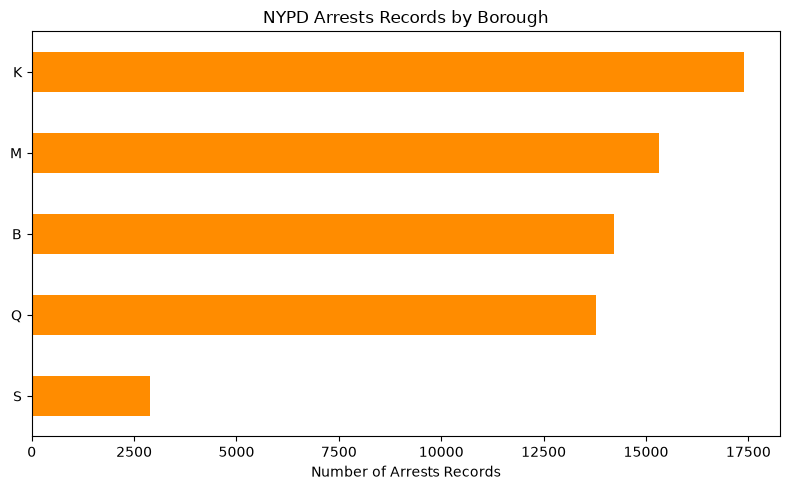

borough
K    17402
M    15324
B    14221
Q    13782
S     2892
Name: count, dtype: int64

In [35]:
plot_category_counts(
    cleaned_arrests_df,
    column= "borough",
    title="NYPD Arrests Records by Borough",
    xlabel="Number of Arrests Records",
    color="darkorange",
)

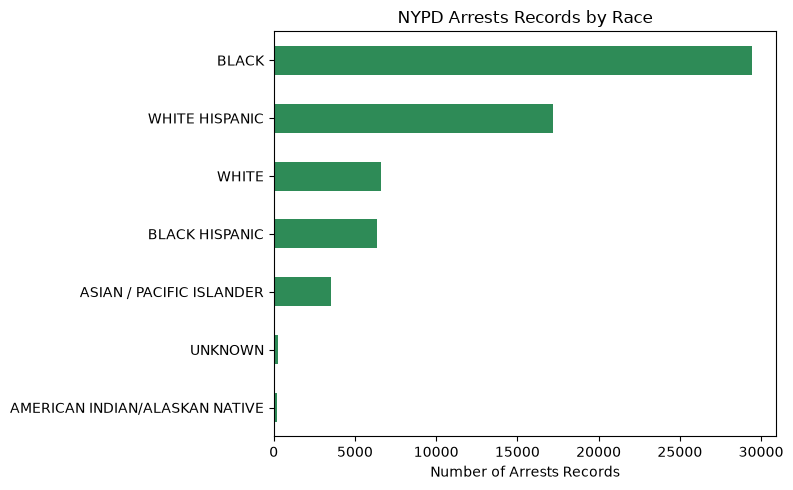

race
BLACK                             29466
WHITE HISPANIC                    17191
WHITE                              6607
BLACK HISPANIC                     6336
ASIAN / PACIFIC ISLANDER           3543
UNKNOWN                             293
AMERICAN INDIAN/ALASKAN NATIVE      185
Name: count, dtype: int64

In [37]:
plot_category_counts(
    cleaned_arrests_df,
    column= "race",
    title="NYPD Arrests Records by Race",
    xlabel="Number of Arrests Records",
    color="seagreen",
)

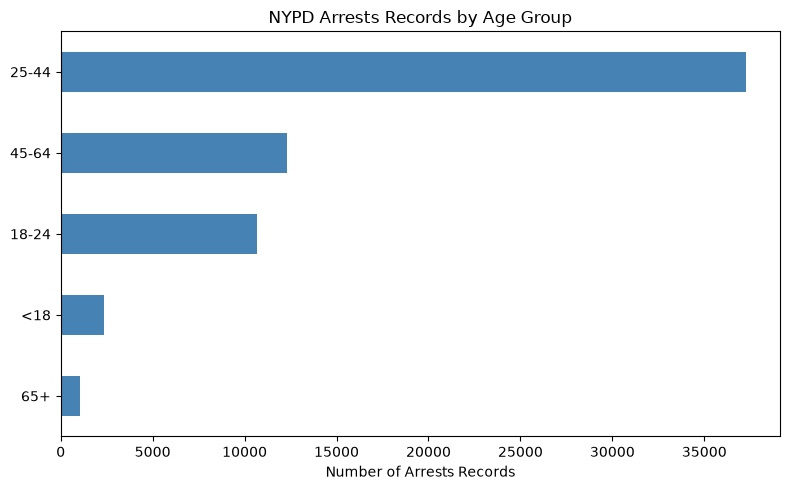

age_group
25-44    37254
45-64    12315
18-24    10684
<18       2327
65+       1041
Name: count, dtype: int64

In [39]:
plot_category_counts(
    cleaned_arrests_df,
    column= "age_group",
    title="NYPD Arrests Records by Age Group",
    xlabel="Number of Arrests Records",
    color="steelblue",
)

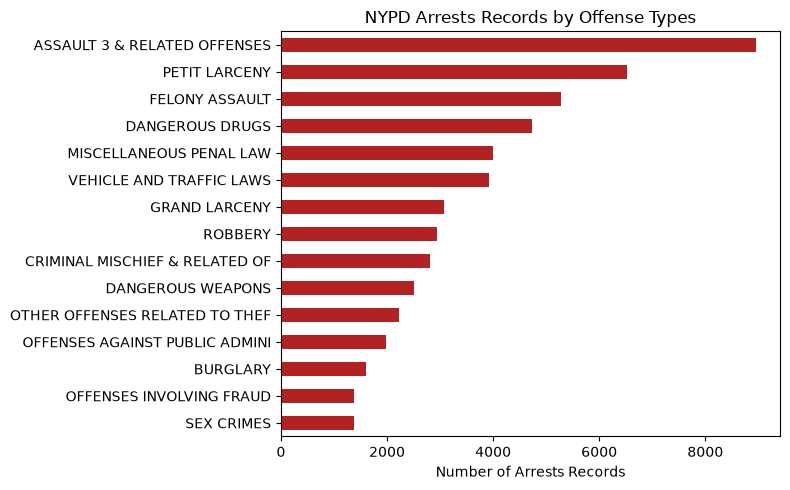

offense_type
ASSAULT 3 & RELATED OFFENSES      8960
PETIT LARCENY                     6526
FELONY ASSAULT                    5288
DANGEROUS DRUGS                   4733
MISCELLANEOUS PENAL LAW           3992
VEHICLE AND TRAFFIC LAWS          3923
GRAND LARCENY                     3068
ROBBERY                           2945
CRIMINAL MISCHIEF & RELATED OF    2817
DANGEROUS WEAPONS                 2509
OTHER OFFENSES RELATED TO THEF    2227
OFFENSES AGAINST PUBLIC ADMINI    1981
BURGLARY                          1599
OFFENSES INVOLVING FRAUD          1384
SEX CRIMES                        1383
Name: count, dtype: int64

In [42]:
plot_category_counts(
    cleaned_arrests_df,
    column= "offense_type",
    title="NYPD Arrests Records by Offense Types",
    xlabel="Number of Arrests Records",
    top_n=15,
    color="firebrick",
)

In [43]:
# Create a geographical dataframe 

MAP_COLUMNS = [
    "arrest_key",
    "arrest_date",
    "borough",
    "offense_type",
    "offense_level",
    "age_group",
    "gender",
    "race",
    "latitude",
    "longitude",
]

map_df = cleaned_arrests_df[MAP_COLUMNS].dropna(
    subset=["latitude","longitude"]
).copy()

map_df = map_df[
    map_df["latitude"].between(40.45,41.00)
    & map_df["longitude"].between(-74.30, -73.65)
].copy()

print(f"Records available for mapping: {len(map_df):}")

map_df.head()

Records available for mapping: 63619


,arrest_key,arrest_date,borough,offense_type,offense_level,age_group,gender,race,latitude,longitude
0,280255493,2024-01-10,M,ROBBERY,F,<18,M,BLACK,40.814845,-73.956312
1,279805419,2024-01-02,K,RAPE,F,25-44,M,WHITE HISPANIC,40.674496,-73.930571
2,279895750,2024-01-03,Q,ASSAULT 3 & RELATED OFFENSES,M,65+,F,WHITE,40.662526,-73.846499
3,280809090,2024-01-19,B,DANGEROUS DRUGS,M,45-64,M,BLACK,40.855793,-73.843908
4,280357135,2024-01-11,K,FELONY ASSAULT,F,25-44,F,BLACK,40.694456,-73.934343
